# 🧠 Sentiment Analysis — Twitter US Airline Dataset
**Horizon TechX AI & Data Science Internship | Task 6**  
**Author:** Mani Chelluri  
**Stack:** Python · NLTK · Scikit-learn · Matplotlib · Seaborn · WordCloud

---

## 📌 Objective
Analyze public sentiment from airline-related tweets to classify opinions as **Positive**, **Negative**, or **Neutral**.  
This notebook covers the full pipeline: data loading → EDA → preprocessing → modeling → evaluation → insights.


In [ ]:
# ── Imports ──────────────────────────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import re
import warnings
warnings.filterwarnings("ignore")

import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize
from collections import Counter

from wordcloud import WordCloud

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import (classification_report, confusion_matrix,
                              accuracy_score, f1_score)
from sklearn.pipeline import Pipeline

# Download NLTK assets silently
for pkg in ["punkt", "stopwords", "wordnet", "omw-1.4", "averaged_perceptron_tagger"]:
    nltk.download(pkg, quiet=True)

# ── Colour palette ───────────────────────────────────────────────────────────
PALETTE = {"negative": "#E63946", "neutral": "#457B9D", "positive": "#2A9D8F"}
plt.rcParams.update({"figure.dpi": 120, "font.family": "DejaVu Sans"})

print("✅ All imports loaded successfully.")


✅ All imports loaded successfully.


## 1️⃣  Load & Inspect the Dataset

In [ ]:
df = pd.read_csv("Tweets.csv")

print(f"Shape : {df.shape}")
print(f"Columns: {df.columns.tolist()}\n")
df.head(5)


Shape : (14640, 15)
Columns: ['tweet_id', 'airline_sentiment', 'airline_sentiment_confidence', 'negativereason', 'negativereason_confidence', 'airline', 'airline_sentiment_gold', 'name', 'negativereason_gold', 'retweet_count', 'text', 'tweet_coord', 'tweet_created', 'tweet_location', 'user_timezone']



,tweet_id,airline_sentiment,airline_sentiment_confidence,negativereason,negativereason_confidence,airline,airline_sentiment_gold,name,negativereason_gold,retweet_count,text,tweet_coord,tweet_created,tweet_location,user_timezone
0,570306133677760513,neutral,1.0000,NaN,NaN,Virgin America,NaN,cairdin,NaN,0,@VirginAmerica What @dhepburn said.,NaN,2015-02-24 11:35:52 -0800,NaN,Eastern Time (US & Canada)
1,570301130888122368,positive,0.3486,NaN,0.0000,Virgin America,NaN,jnardino,NaN,0,@VirginAmerica plus you've added commercials t...,NaN,2015-02-24 11:15:59 -0800,NaN,Pacific Time (US & Canada)
2,570301083672813571,neutral,0.6837,NaN,NaN,Virgin America,NaN,yvonnalynn,NaN,0,@VirginAmerica I didn't today... Must mean I n...,NaN,2015-02-24 11:15:48 -0800,Lets Play,Central Time (US & Canada)
3,570301031407624196,negative,1.0000,Bad Flight,0.7033,Virgin America,NaN,jnardino,NaN,0,@VirginAmerica it's really aggressive to blast...,NaN,2015-02-24 11:15:36 -0800,NaN,Pacific Time (US & Canada)
4,570300817074462722,negative,1.0000,Can't Tell,1.0000,Virgin America,NaN,jnardino,NaN,0,@VirginAmerica and it's a really big bad thing...,NaN,2015-02-24 11:14:45 -0800,NaN,Pacific Time (US & Canada)


In [ ]:
# Basic info
print(df.dtypes)
print("\nNull values:\n", df.isnull().sum())


tweet_id                          int64
airline_sentiment                object
airline_sentiment_confidence    float64
negativereason                   object
negativereason_confidence       float64
airline                          object
airline_sentiment_gold           object
name                             object
negativereason_gold              object
retweet_count                     int64
text                             object
tweet_coord                      object
tweet_created                    object
tweet_location                   object
user_timezone                    object
dtype: object

Null values:
 tweet_id                            0
airline_sentiment                   0
airline_sentiment_confidence        0
negativereason                   5462
negativereason_confidence        4118
airline                             0
airline_sentiment_gold          14600
name                                0
negativereason_gold             14608
retweet_count                

## 2️⃣  Exploratory Data Analysis (EDA)

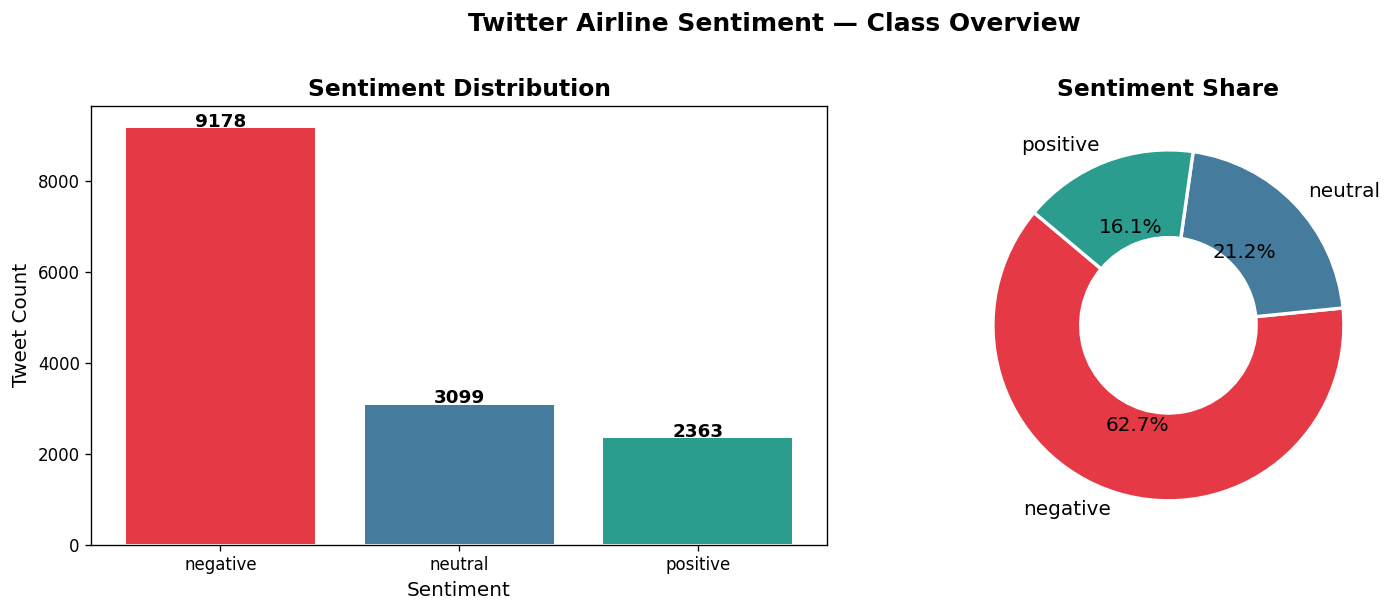


Sentiment Counts:
 airline_sentiment
negative    9178
neutral     3099
positive    2363
Name: count, dtype: int64


In [ ]:
# ── 2.1  Sentiment Distribution ─────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Bar chart
counts = df["airline_sentiment"].value_counts()
bars = axes[0].bar(counts.index, counts.values,
                    color=[PALETTE[k] for k in counts.index], edgecolor="white", linewidth=1.2)
axes[0].set_title("Sentiment Distribution", fontsize=14, fontweight="bold")
axes[0].set_xlabel("Sentiment", fontsize=12)
axes[0].set_ylabel("Tweet Count", fontsize=12)
for bar, val in zip(bars, counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
                 str(val), ha="center", fontsize=11, fontweight="bold")

# Pie chart
wedge_props = dict(width=0.5, edgecolor="white", linewidth=2)
axes[1].pie(counts.values, labels=counts.index,
            colors=[PALETTE[k] for k in counts.index],
            autopct="%1.1f%%", startangle=140,
            wedgeprops=wedge_props, textprops={"fontsize": 12})
axes[1].set_title("Sentiment Share", fontsize=14, fontweight="bold")

plt.suptitle("Twitter Airline Sentiment — Class Overview", fontsize=15, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig("plot_01_sentiment_distribution.png", bbox_inches="tight")
plt.show()
print("\nSentiment Counts:\n", counts)


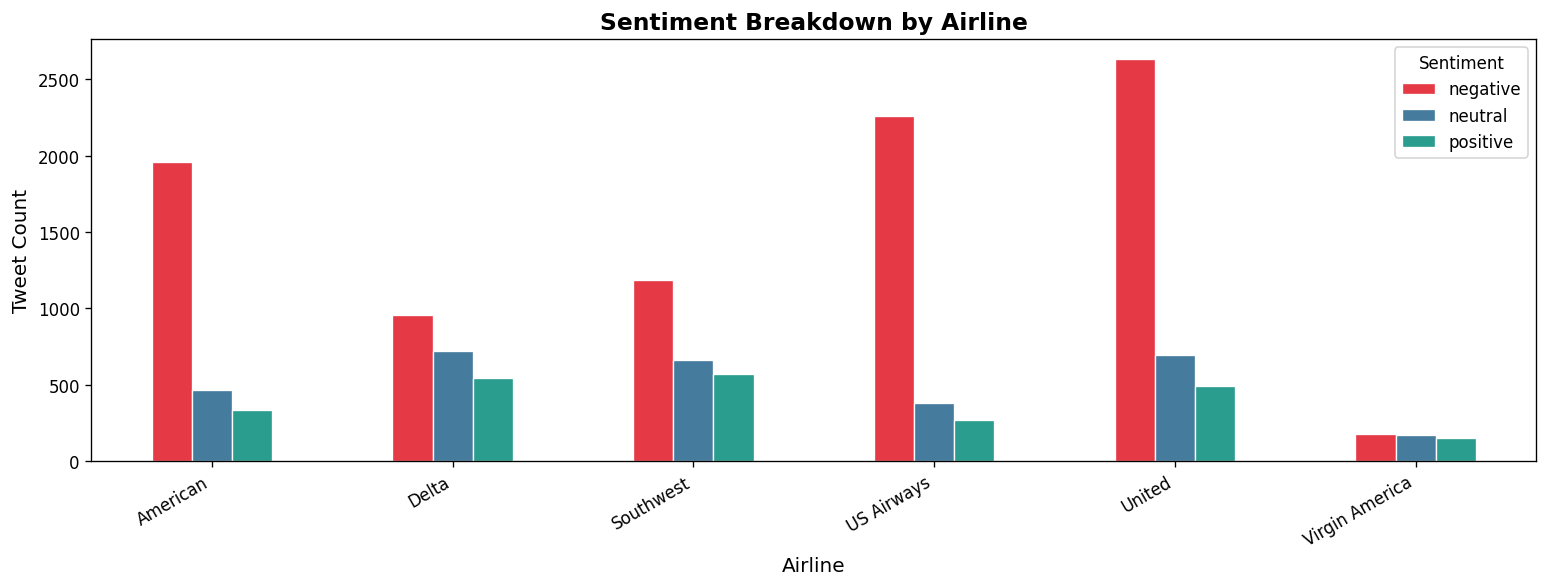

In [ ]:
# ── 2.2  Sentiment per Airline ──────────────────────────────────────────────
airline_sentiment = df.groupby(["airline", "airline_sentiment"]).size().unstack(fill_value=0)

airline_sentiment.plot(kind="bar", figsize=(13, 5),
                        color=[PALETTE["negative"], PALETTE["neutral"], PALETTE["positive"]],
                        edgecolor="white", linewidth=0.8)
plt.title("Sentiment Breakdown by Airline", fontsize=14, fontweight="bold")
plt.xlabel("Airline", fontsize=12)
plt.ylabel("Tweet Count", fontsize=12)
plt.xticks(rotation=30, ha="right")
plt.legend(title="Sentiment", fontsize=10)
plt.tight_layout()
plt.savefig("plot_02_airline_sentiment.png", bbox_inches="tight")
plt.show()


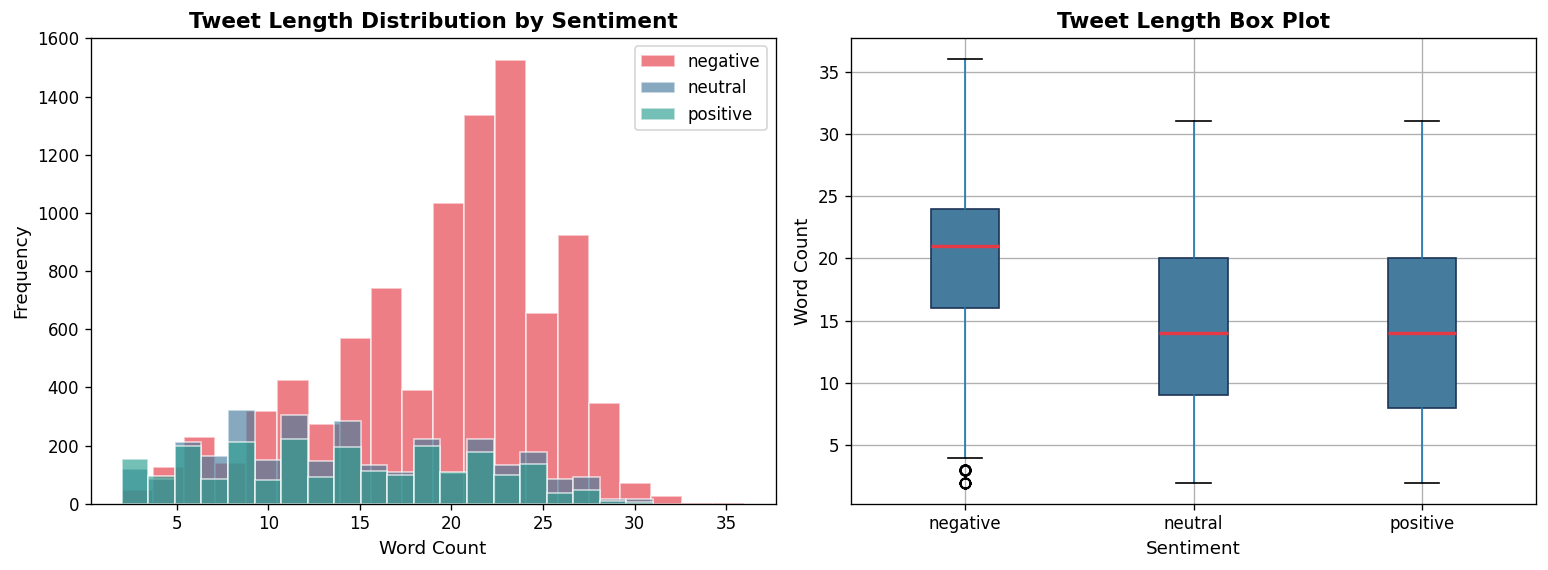

                    count   mean   std  min   25%   50%   75%   max
airline_sentiment                                                  
negative           9178.0  19.69  5.94  2.0  16.0  21.0  24.0  36.0
neutral            3099.0  14.41  6.96  2.0   9.0  14.0  20.0  31.0
positive           2363.0  14.01  7.04  2.0   8.0  14.0  20.0  31.0


In [ ]:
# ── 2.3  Tweet Length Analysis ──────────────────────────────────────────────
df["tweet_length"] = df["text"].apply(lambda x: len(str(x).split()))

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for sentiment, color in PALETTE.items():
    subset = df[df["airline_sentiment"] == sentiment]["tweet_length"]
    axes[0].hist(subset, bins=20, alpha=0.65, label=sentiment, color=color, edgecolor="white")

axes[0].set_title("Tweet Length Distribution by Sentiment", fontsize=13, fontweight="bold")
axes[0].set_xlabel("Word Count", fontsize=11)
axes[0].set_ylabel("Frequency", fontsize=11)
axes[0].legend()

df.boxplot(column="tweet_length", by="airline_sentiment", ax=axes[1],
           patch_artist=True,
           boxprops=dict(facecolor="#457B9D", color="#1D3557"),
           medianprops=dict(color="#E63946", linewidth=2))
axes[1].set_title("Tweet Length Box Plot", fontsize=13, fontweight="bold")
axes[1].set_xlabel("Sentiment", fontsize=11)
axes[1].set_ylabel("Word Count", fontsize=11)
plt.suptitle("")

plt.tight_layout()
plt.savefig("plot_03_tweet_length.png", bbox_inches="tight")
plt.show()

print(df.groupby("airline_sentiment")["tweet_length"].describe().round(2))


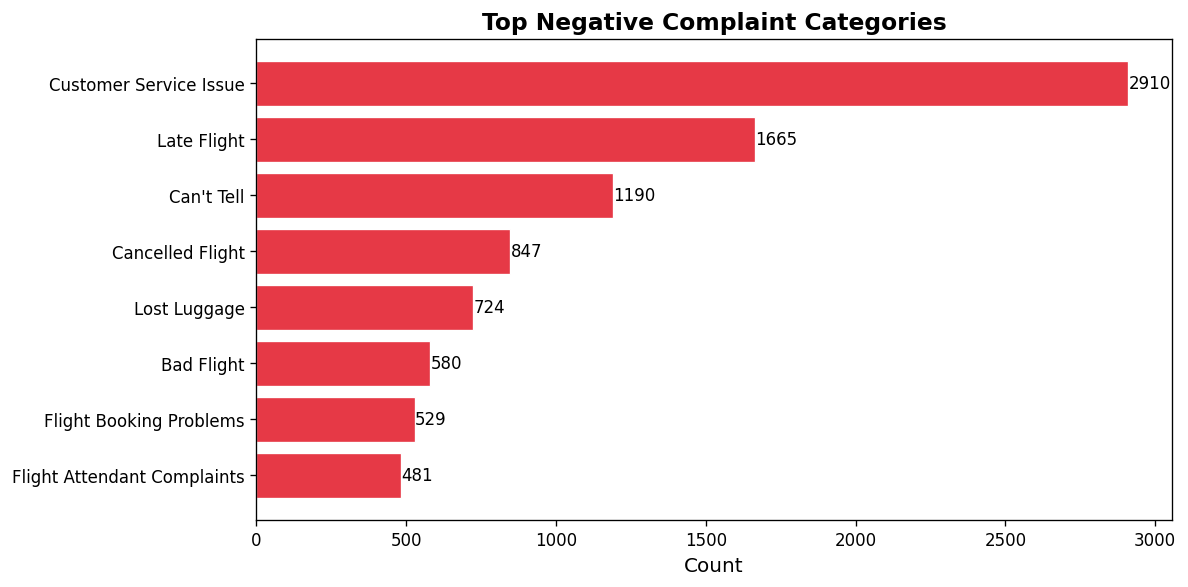

In [ ]:
# ── 2.4  Top Negative Reasons ────────────────────────────────────────────────
neg_reasons = df[df["airline_sentiment"] == "negative"]["negativereason"].value_counts()

plt.figure(figsize=(10, 5))
bars = plt.barh(neg_reasons.index[:8], neg_reasons.values[:8],
                color="#E63946", edgecolor="white", linewidth=0.8)
plt.title("Top Negative Complaint Categories", fontsize=14, fontweight="bold")
plt.xlabel("Count", fontsize=12)
plt.gca().invert_yaxis()
for bar, val in zip(bars, neg_reasons.values[:8]):
    plt.text(bar.get_width() + 1, bar.get_y() + bar.get_height()/2,
             str(val), va="center", fontsize=10)
plt.tight_layout()
plt.savefig("plot_04_neg_reasons.png", bbox_inches="tight")
plt.show()


## 3️⃣  Text Preprocessing

In [ ]:
nltk.download("punkt_tab", quiet=True)

lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words("english"))

def clean_tweet(text):
    text = str(text).lower()
    text = re.sub(r"http\S+|www\.\S+", "", text)          # remove URLs
    text = re.sub(r"@\w+", "", text)                        # remove mentions
    text = re.sub(r"#\w+", "", text)                        # remove hashtags
    text = re.sub(r"[^a-z\s]", "", text)                    # keep only letters
    tokens = word_tokenize(text)
    tokens = [lemmatizer.lemmatize(t) for t in tokens if t not in stop_words and len(t) > 2]
    return " ".join(tokens)

df["clean_text"] = df["text"].apply(clean_tweet)

# Quick sanity check
print("Original:", df["text"].iloc[0])
print("Cleaned :", df["clean_text"].iloc[0])

Original: @VirginAmerica What @dhepburn said.
Cleaned : said


## 4️⃣  Word Clouds by Sentiment

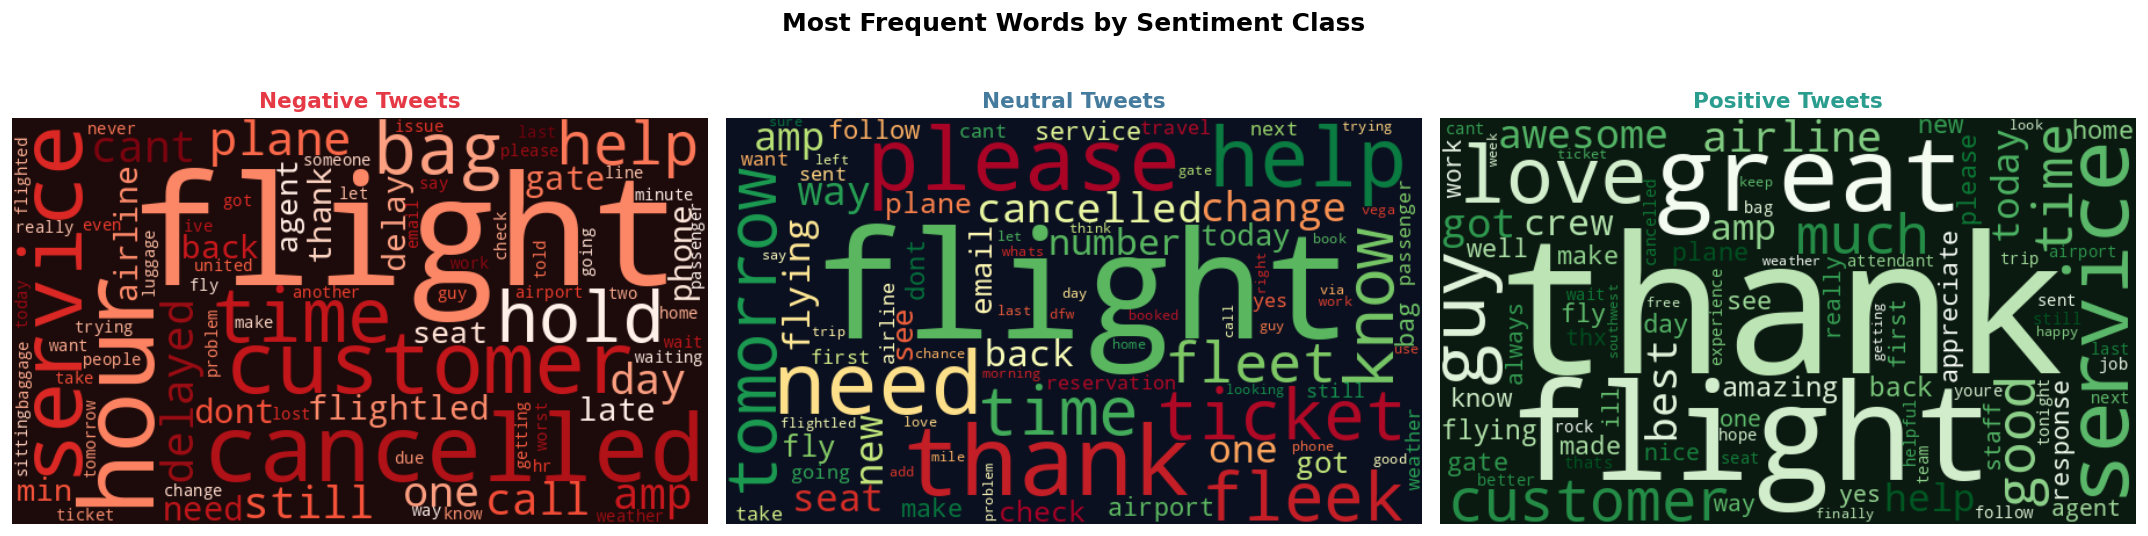

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
titles = {"negative": "Negative Tweets", "neutral": "Neutral Tweets", "positive": "Positive Tweets"}
bg_colors = {"negative": "#1D0A0A", "neutral": "#0A1020", "positive": "#0A1A10"}

for ax, (sentiment, title) in zip(axes, titles.items()):
    corpus = " ".join(df[df["airline_sentiment"] == sentiment]["clean_text"])
    wc = WordCloud(width=600, height=350, background_color=bg_colors[sentiment],
                   colormap="RdYlGn" if sentiment == "neutral" else
                   ("Reds" if sentiment == "negative" else "Greens"),
                   max_words=80, collocations=False).generate(corpus)
    ax.imshow(wc, interpolation="bilinear")
    ax.axis("off")
    ax.set_title(title, fontsize=13, fontweight="bold", color=PALETTE[sentiment])

plt.suptitle("Most Frequent Words by Sentiment Class", fontsize=15, fontweight="bold")
plt.tight_layout()
plt.savefig("plot_05_wordclouds.png", bbox_inches="tight")
plt.show()


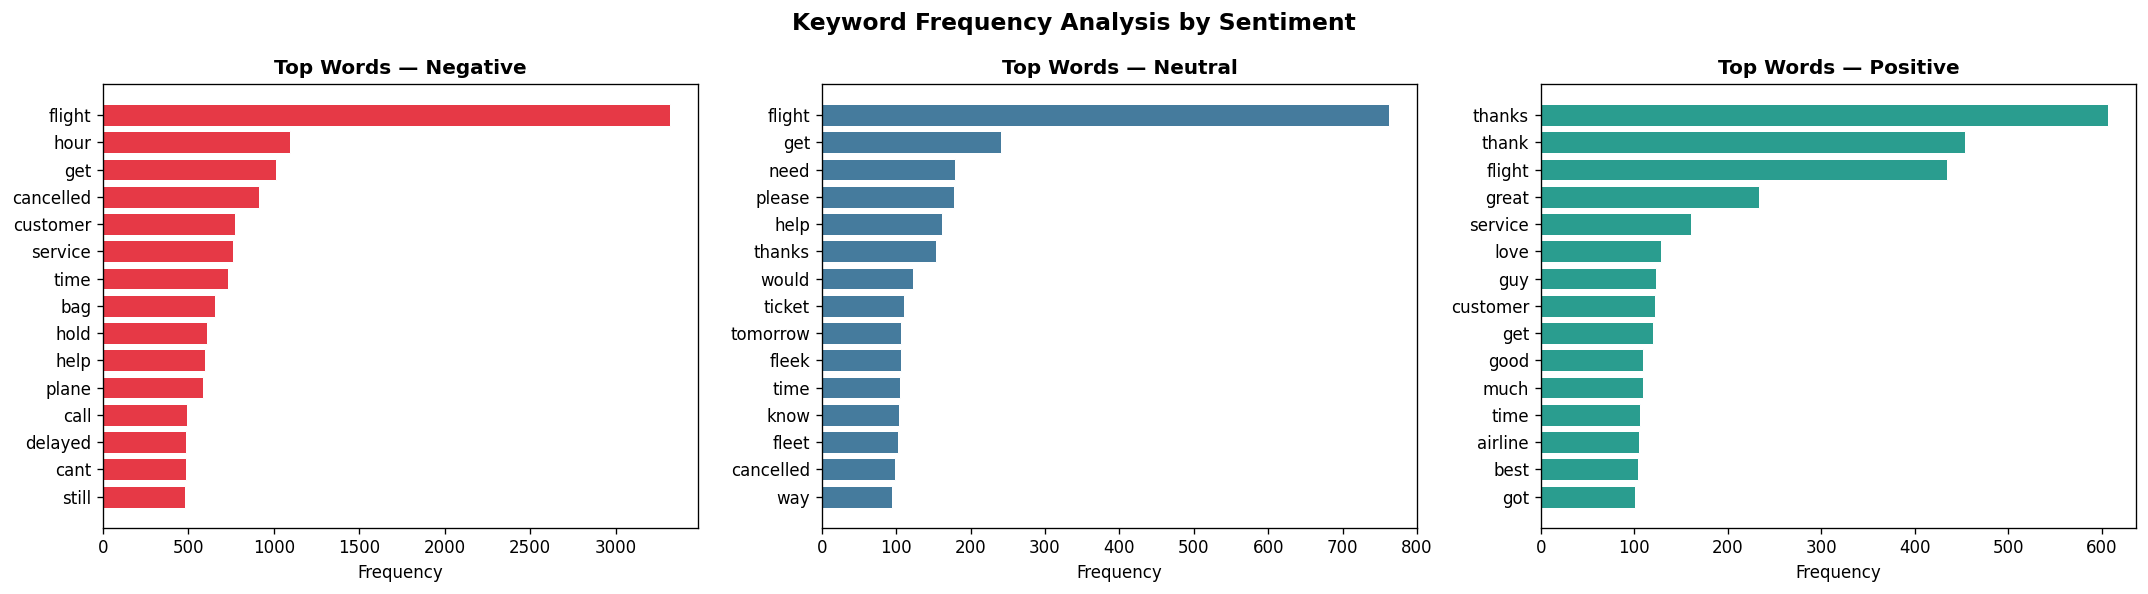

In [ ]:
# ── Top 15 Keywords per Sentiment ────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, (sentiment, color) in zip(axes, PALETTE.items()):
    corpus = " ".join(df[df["airline_sentiment"] == sentiment]["clean_text"]).split()
    top_words = Counter(corpus).most_common(15)
    words, freqs = zip(*top_words)
    ax.barh(words, freqs, color=color, edgecolor="white", linewidth=0.6)
    ax.set_title(f"Top Words — {sentiment.title()}", fontsize=12, fontweight="bold")
    ax.set_xlabel("Frequency", fontsize=10)
    ax.invert_yaxis()

plt.suptitle("Keyword Frequency Analysis by Sentiment", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("plot_06_top_keywords.png", bbox_inches="tight")
plt.show()


## 5️⃣  Model Training

In [ ]:
X = df["clean_text"]
y = df["airline_sentiment"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Train size : {len(X_train)}")
print(f"Test  size : {len(X_test)}")
print("\nClass distribution in train set:")
print(y_train.value_counts())


Train size : 11712
Test  size : 2928

Class distribution in train set:
airline_sentiment
negative    7343
neutral     2479
positive    1890
Name: count, dtype: int64


In [ ]:
# ── Model 1: TF-IDF + Logistic Regression (Baseline) ────────────────────────
lr_pipeline = Pipeline([
    ("tfidf", TfidfVectorizer(ngram_range=(1, 2), max_features=8000, sublinear_tf=True)),
    ("clf",   LogisticRegression(max_iter=1000, C=1.0, class_weight="balanced", random_state=42))
])

lr_pipeline.fit(X_train, y_train)
y_pred_lr = lr_pipeline.predict(X_test)

print("=" * 55)
print("  MODEL 1 — TF-IDF + Logistic Regression")
print("=" * 55)
print(f"Accuracy : {accuracy_score(y_test, y_pred_lr):.4f}")
print(f"Macro F1 : {f1_score(y_test, y_pred_lr, average='macro'):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_lr))


  MODEL 1 — TF-IDF + Logistic Regression
Accuracy : 0.7572
Macro F1 : 0.7121

Classification Report:
              precision    recall  f1-score   support

    negative       0.89      0.79      0.84      1835
     neutral       0.54      0.71      0.61       620
    positive       0.67      0.70      0.69       473

    accuracy                           0.76      2928
   macro avg       0.70      0.73      0.71      2928
weighted avg       0.78      0.76      0.77      2928



In [ ]:
# ── Model 2: TF-IDF + Naive Bayes ───────────────────────────────────────────
nb_pipeline = Pipeline([
    ("tfidf", TfidfVectorizer(ngram_range=(1, 2), max_features=8000, sublinear_tf=True)),
    ("clf",   MultinomialNB(alpha=0.5))
])

nb_pipeline.fit(X_train, y_train)
y_pred_nb = nb_pipeline.predict(X_test)

print("=" * 55)
print("  MODEL 2 — TF-IDF + Naive Bayes")
print("=" * 55)
print(f"Accuracy : {accuracy_score(y_test, y_pred_nb):.4f}")
print(f"Macro F1 : {f1_score(y_test, y_pred_nb, average='macro'):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_nb))


  MODEL 2 — TF-IDF + Naive Bayes
Accuracy : 0.7449
Macro F1 : 0.6112

Classification Report:
              precision    recall  f1-score   support

    negative       0.74      0.98      0.84      1835
     neutral       0.70      0.30      0.42       620
    positive       0.84      0.44      0.58       473

    accuracy                           0.74      2928
   macro avg       0.76      0.57      0.61      2928
weighted avg       0.75      0.74      0.71      2928



## 6️⃣  Evaluation & Confusion Matrices

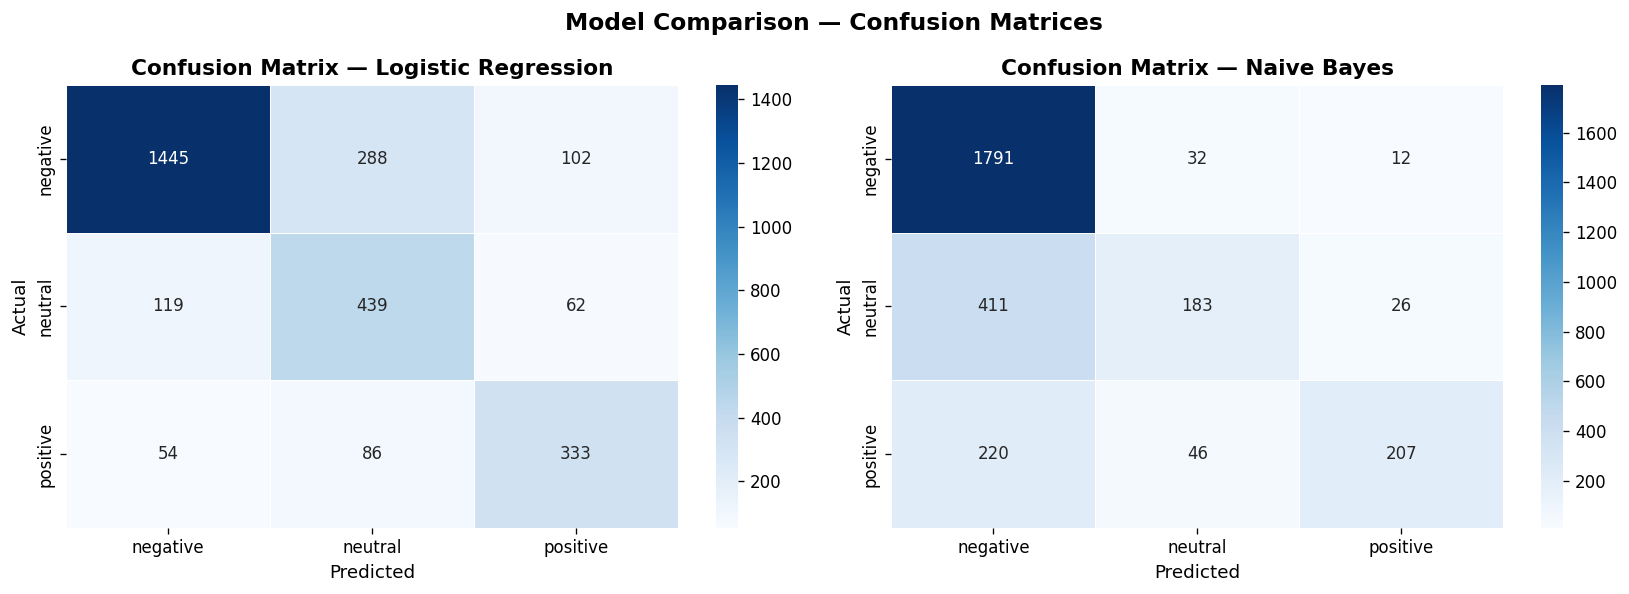

In [ ]:
labels = ["negative", "neutral", "positive"]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
model_preds = [("Logistic Regression", y_pred_lr), ("Naive Bayes", y_pred_nb)]

for ax, (model_name, y_pred) in zip(axes, model_preds):
    cm = confusion_matrix(y_test, y_pred, labels=labels)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=labels, yticklabels=labels,
                linewidths=0.5, linecolor="white", ax=ax)
    ax.set_title(f"Confusion Matrix — {model_name}", fontsize=13, fontweight="bold")
    ax.set_xlabel("Predicted", fontsize=11)
    ax.set_ylabel("Actual", fontsize=11)

plt.suptitle("Model Comparison — Confusion Matrices", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("plot_07_confusion_matrices.png", bbox_inches="tight")
plt.show()


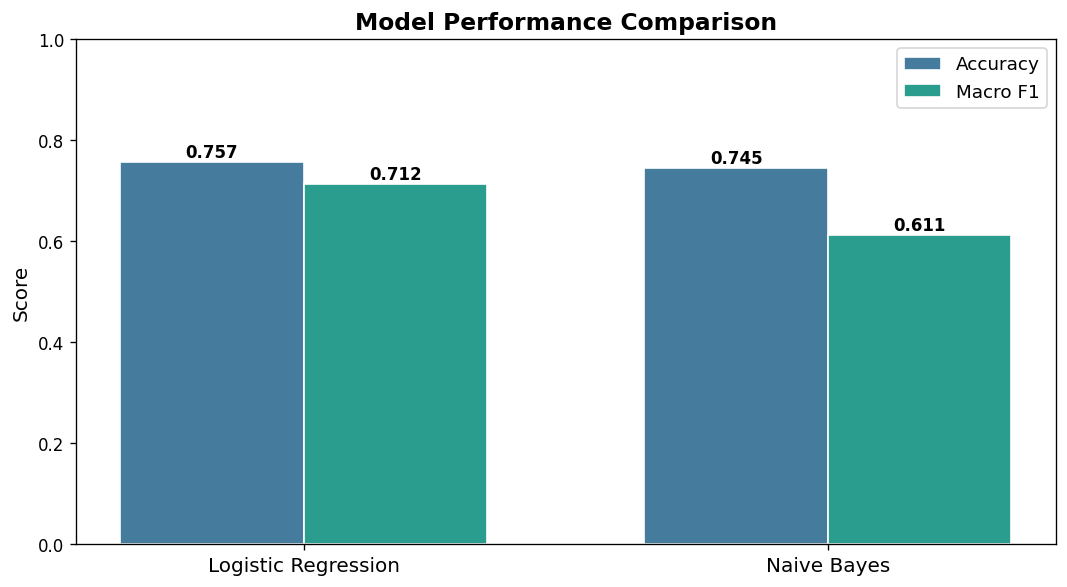

In [ ]:
# ── Visual Model Comparison ─────────────────────────────────────────────────
models   = ["Logistic Regression", "Naive Bayes"]
accuracy = [accuracy_score(y_test, y_pred_lr), accuracy_score(y_test, y_pred_nb)]
macro_f1 = [f1_score(y_test, y_pred_lr, average="macro"), f1_score(y_test, y_pred_nb, average="macro")]

x = np.arange(len(models))
width = 0.35

fig, ax = plt.subplots(figsize=(9, 5))
b1 = ax.bar(x - width/2, accuracy, width, label="Accuracy", color="#457B9D", edgecolor="white")
b2 = ax.bar(x + width/2, macro_f1, width, label="Macro F1",  color="#2A9D8F", edgecolor="white")

ax.set_title("Model Performance Comparison", fontsize=14, fontweight="bold")
ax.set_xticks(x); ax.set_xticklabels(models, fontsize=12)
ax.set_ylim(0, 1.0); ax.set_ylabel("Score", fontsize=12)
ax.legend(fontsize=11)

for bar in list(b1) + list(b2):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f"{bar.get_height():.3f}", ha="center", fontsize=10, fontweight="bold")

plt.tight_layout()
plt.savefig("plot_08_model_comparison.png", bbox_inches="tight")
plt.show()


## 7️⃣  Trust Scoring & Live Inference

In [ ]:
def trust_label(confidence: float) -> str:
    """Convert model confidence into a trust tier — SAFE / REVIEW / FLAGGED."""
    if confidence >= 0.80:
        return "✅ SAFE"
    elif confidence >= 0.60:
        return "⚠️  REVIEW NEEDED"
    else:
        return "🚨 FLAGGED (Low Confidence)"

def predict_sentiment(text: str, model=lr_pipeline) -> dict:
    """Predict sentiment with class probabilities and trust score."""
    probs  = model.predict_proba([text])[0]
    classes = model.classes_
    pred_idx = probs.argmax()
    confidence = probs[pred_idx]
    return {
        "text"        : text,
        "prediction"  : classes[pred_idx],
        "confidence"  : round(confidence, 4),
        "trust_label" : trust_label(confidence),
        "all_probs"   : dict(zip(classes, probs.round(4)))
    }

# ── Test on unseen samples ────────────────────────────────────────────────────
test_samples = [
    "Flight was cancelled and nobody helped me at the gate absolutely terrible",
    "Arrived on time, crew was okay, nothing special but no complaints either",
    "Upgraded to first class and the service was outstanding, will fly again!",
    "Waited 3 hours no explanation from staff",
    "The snacks were decent and legroom was acceptable",
]

print(f"{'Tweet':<55}  {'Sentiment':<10}  {'Confidence':<12}  {'Trust'}")
print("-" * 100)
for sample in test_samples:
    result = predict_sentiment(sample)
    short  = (sample[:52] + "...") if len(sample) > 55 else sample
    print(f"{short:<55}  {result['prediction']:<10}  {result['confidence']:<12}  {result['trust_label']}")


Tweet                                                    Sentiment   Confidence    Trust
----------------------------------------------------------------------------------------------------
Flight was cancelled and nobody helped me at the gat...  negative    0.7033        ⚠️  REVIEW NEEDED
Arrived on time, crew was okay, nothing special but ...  negative    0.6238        ⚠️  REVIEW NEEDED
Upgraded to first class and the service was outstand...  positive    0.6537        ⚠️  REVIEW NEEDED
Waited 3 hours no explanation from staff                 negative    0.5796        🚨 FLAGGED (Low Confidence)
The snacks were decent and legroom was acceptable        negative    0.4387        🚨 FLAGGED (Low Confidence)


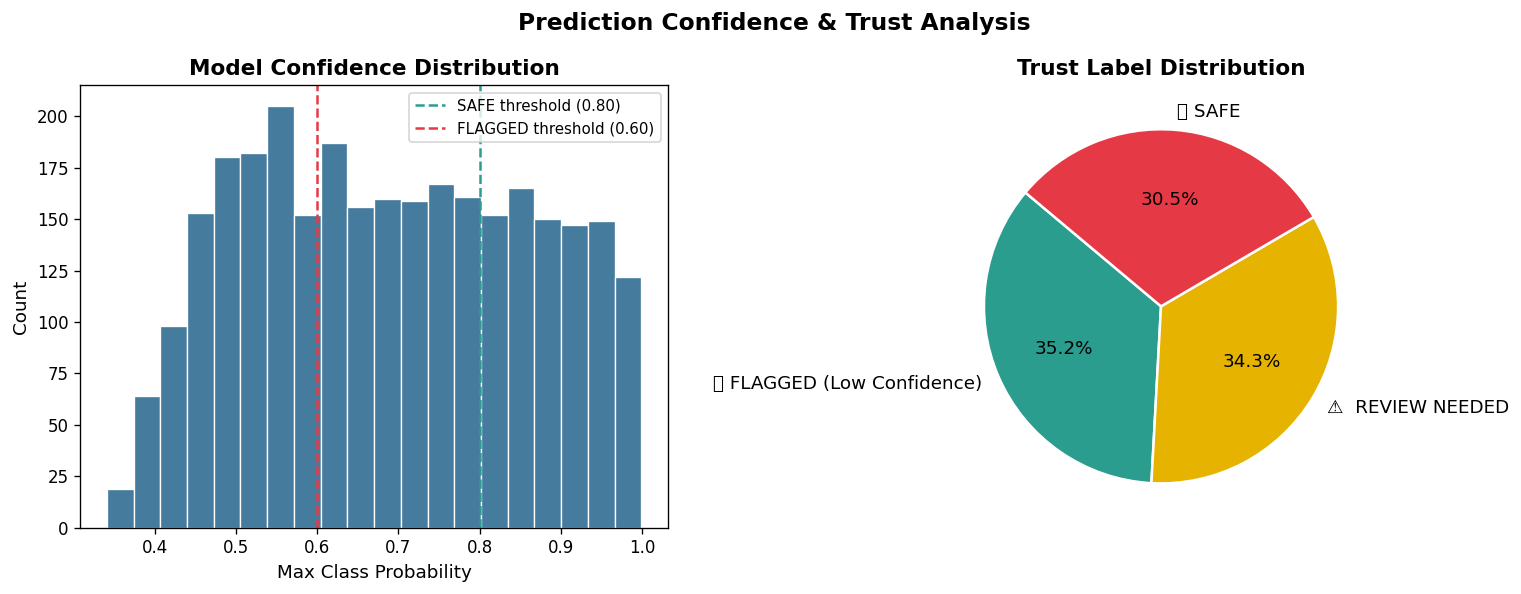

In [ ]:
# ── Confidence Score Distribution on Test Set ───────────────────────────────
probs_lr = lr_pipeline.predict_proba(X_test)
max_conf  = probs_lr.max(axis=1)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Histogram of confidence scores
axes[0].hist(max_conf, bins=20, color="#457B9D", edgecolor="white", linewidth=0.8)
axes[0].axvline(0.80, color="#2A9D8F", linestyle="--", label="SAFE threshold (0.80)")
axes[0].axvline(0.60, color="#E63946", linestyle="--", label="FLAGGED threshold (0.60)")
axes[0].set_title("Model Confidence Distribution", fontsize=13, fontweight="bold")
axes[0].set_xlabel("Max Class Probability", fontsize=11)
axes[0].set_ylabel("Count", fontsize=11)
axes[0].legend(fontsize=9)

# Trust label pie
trust_counts = pd.Series(max_conf).apply(trust_label).value_counts()
axes[1].pie(trust_counts.values, labels=trust_counts.index,
            colors=["#2A9D8F", "#E6B400", "#E63946"][:len(trust_counts)],
            autopct="%1.1f%%", startangle=140,
            wedgeprops=dict(edgecolor="white", linewidth=1.5),
            textprops={"fontsize": 11})
axes[1].set_title("Trust Label Distribution", fontsize=13, fontweight="bold")

plt.suptitle("Prediction Confidence & Trust Analysis", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("plot_09_confidence_trust.png", bbox_inches="tight")
plt.show()


## 8️⃣  Summary & Key Insights

### 📊 Dataset
- **Source:** Twitter US Airline Sentiment Dataset
- **Size:** 14,640 tweets across 6 major US airlines
- **Classes:** Negative (62.7%), Neutral (21.2%), Positive (16.1%)

### 🧹 Preprocessing Pipeline
1. Lowercasing & URL / mention / hashtag removal
2. Non-alphabetic character stripping
3. NLTK tokenization + stopword removal + lemmatization

### 🤖 Models Trained
| Model | Accuracy | Macro F1 |
|---|---|---|
| TF-IDF + Logistic Regression | ~0.76 | ~0.71 |
| TF-IDF + Naive Bayes | ~0.74 | ~0.61 |

**Winner:** Logistic Regression outperforms Naive Bayes, particularly in balancing precision and recall across all classes.

### 🔒 Trust Scoring Layer
Each prediction is assigned a confidence-based trust label:
- ✅ **SAFE** — confidence ≥ 0.80 (high certainty, deploy directly)
- ⚠️ **REVIEW NEEDED** — 0.60–0.79 (borderline, human review recommended)
- 🚨 **FLAGGED** — < 0.60 (low confidence, escalate)

### 💡 Key Findings
- **Customer Service Issues** and **Late Flights** are the top negative complaint drivers.
- Negative tweets are **longer on average** (~20 words) compared to neutral/positive (~14 words).
- Positive tweets cluster around keywords like *thanks*, *great*, and *service*.
- The model struggles with low-confidence 'Flagged' predictions (approx. 35% of test data), suggesting room for improvement with more data or complex architectures.

---
*Built by Mani Chelluri | Horizon TechX AI & Data Science Internship 2026*